# TabM：任务时间与能耗预测（v6 分离特征版）

本 Notebook 对应 `buildTaskFeatures_time_energy_v6.py`，整体结构、训练流程和绘图方式保持原来的简化版风格。

最终只训练两个回归目标：

- `task_duration_min`：去除 `speed < 0.2` 暂停时间后的任务时长，单位分钟；
- `total_energy_soc_delta_pct`：任务 SOC 能耗，单位百分点。

两套模型使用不同输入：

- **时间模型**：路线/地形 + 历史速度 + 历史耗时 + 相似任务；
- **能耗模型**：路线/地形 + 历史能耗 + 单位里程能耗 + 相似任务能耗；
- 速度不是预测目标，只是已完成历史任务中的中间量，用于增强时间预测；
- 历史耗时/历史速度不进入能耗模型；
- 两个模型分别进行缺失值处理、标准化、早停、完整训练集重训和模型保存。

流程：读取 JSON → 按时间顺序划分 → 各目标使用各自特征 → 中位数填补与标准化 → 早停确定 epoch → 完整训练集重训 → 测试集评价 → 绘图与保存结果。


## 1. 首次安装或修复依赖

首次安装时运行第一组命令。你之前出现过 `backend_agg` 导入失败；若再次出现，运行第二组“清洁重装 Matplotlib”命令，然后 **重启 Kernel**。

In [45]:
# 首次安装依赖时取消注释并运行：
# %pip install -U numpy pandas scikit-learn joblib torch tabm matplotlib matplotlib-inline

# # Matplotlib 的 backend_agg 损坏时，取消注释并运行；完成后必须重启 Kernel：
# %pip install --force-reinstall --no-deps matplotlib==3.11.1
# %pip uninstall -y matplotlib matplotlib-inline
# %pip install --no-cache-dir --force-reinstall matplotlib matplotlib-inline

## 2. 导入依赖与配置

In [46]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json, math, random, re
from copy import deepcopy
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Image as IPythonImage
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from torch.utils.data import DataLoader, TensorDataset

# ===== 必须在 import matplotlib.pyplot 之后，任何绘图之前立刻重置 =====
import matplotlib
matplotlib.rcdefaults()                 # ① 还原 rcParams
matplotlib.use("Agg")                   # ② 强制 backend（和 MPLBACKEND 对应）
import matplotlib.pyplot as plt
plt.style.use("default")                # ③ 切回 default style（清除 dark_background / seaborn 残留）

# ④ 关键：先 delete 掉可能注入的所有 Jupyter / matplotlib_inline 配置（如果有的话）
if "pylab_setup" in dir():
    pass

# ===== 从白纸开始，显式设置所有参数 =====
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.facecolor":  "white",
    "savefig.transparent": False,

    "text.color":         "black",
    "axes.edgecolor":     "black",
    "axes.labelcolor":    "black",
    "xtick.color":        "black",
    "ytick.color":        "black",
    "xtick.labelcolor":   "black",
    "ytick.labelcolor":   "black",

    "font.family":        "sans-serif",
    "font.sans-serif":    [
        "Microsoft YaHei", "SimHei", "SimSun",
        "Microsoft YaHei UI", "DejaVu Sans",
    ],
    "axes.unicode_minus": False,

    "legend.facecolor":   "white",
    "legend.edgecolor":   "#888888",
    "legend.labelcolor":  "black",
    "legend.framealpha":  1.0,

    "grid.alpha":         0.2,
    "grid.color":         "#cccccc",
    "axes.grid":          False,

    "axes.titlecolor":    "black",
})

# 现在再设置 pandas
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]    # 字体设置
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

RANDOM_STATE = 42

def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch 设备：", DEVICE)
if DEVICE.type == "cuda":
    print("GPU：", torch.cuda.get_device_name(0))

PyTorch 设备： cpu


In [47]:
# 1、路径配置
PROJECT_ROOT = Path(os.getcwd()).resolve().parent

TARGET_AREA = "TianChi"

# 使用“层次聚类增强版”特征文件
DATA_FILE = PROJECT_ROOT / "data" / TARGET_AREA / f"任务特征和标签-{TARGET_AREA}_层次聚类.json"
OUTPUT_DIR = PROJECT_ROOT / "target" / "TabM_TimeEnergy_V7_ODCluster"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2、OD / 空间特征配置
# ============================================================
# 说明：
# 1) degree 差与米制位移基本是重复信息，因此默认只把米制位移送入模型；
# 2) degree 差仍保留在 JSON 中，便于分析/绘图；
# 3) start/end zone 以及 od_zone_pair 都是“类别特征”，后续做 One-Hot，
#    不能直接当作连续数值使用。
OD_NUMERIC_FEATURE_COLS = [
    # "od_midpoint_longitude",
    # "od_midpoint_latitude",
    # "od_delta_east_m",
    # "od_delta_north_m",
    # "start_zone_distance_m",
    # "end_zone_distance_m",
]


OD_CATEGORICAL_FEATURE_COLS = [
    # "start_zone_id",
    # "end_zone_id",
    # "od_zone_pair",
]

# ============================================================
# 3、时间模型特征
# ============================================================
TIME_BASE_NUMERIC_FEATURE_COLS = [
    # 当前路线 / 地形
    "straight_line_distance_m",
    "planned_total_distance_m",
    "planned_to_straight_distance_ratio",
    "endpoint_altitude_change_m",
    "planned_slope_mean",
    "planned_cumulative_ascent_m",
    "planned_cumulative_descent_m",

    # 同车近期
    "vehicle_today_speed_mean_mps",
    "vehicle_recent10_duration_mean_sec",
    "vehicle_time_gap_since_prev_task_min",

    # 同车 + 相似路线
    "vehicle_similar_top5_duration_mean_sec",

    # 全局相似路线
    "similar_top5_duration_mean_sec",
    "similar_top5_duration_std_sec",
    "similar_nearest_od_distance_m",
    "similar_nearest_time_gap_min",
]

TIME_NUMERIC_FEATURE_COLS = (
    TIME_BASE_NUMERIC_FEATURE_COLS
    + OD_NUMERIC_FEATURE_COLS
)
TIME_CATEGORICAL_FEATURE_COLS = OD_CATEGORICAL_FEATURE_COLS.copy()
TIME_FEATURE_COLS = (
    TIME_NUMERIC_FEATURE_COLS
    + TIME_CATEGORICAL_FEATURE_COLS
)

# ============================================================
# 4、能耗模型特征
# ============================================================
ENERGY_BASE_NUMERIC_FEATURE_COLS = [
    # 当前路线 / 地形
    "straight_line_distance_m",
    "planned_total_distance_m",
    "planned_to_straight_distance_ratio",
    "endpoint_altitude_change_m",
    "planned_slope_mean",
    "planned_cumulative_ascent_m",
    "planned_cumulative_descent_m",

    # 同车近期
    "vehicle_today_speed_mean_mps",
    "vehicle_recent5_energy_mean_pct",
    "vehicle_time_gap_since_prev_task_min",

    # 同车 + 相似路线
    "vehicle_similar_top5_energy_mean_pct",

    # 全局相似路线
    "similar_top5_energy_mean_pct",
    "similar_top5_energy_std_pct",
    "similar_nearest_od_distance_m",
    "similar_nearest_time_gap_min",
]

ENERGY_NUMERIC_FEATURE_COLS = (
    ENERGY_BASE_NUMERIC_FEATURE_COLS
    + OD_NUMERIC_FEATURE_COLS
)
ENERGY_CATEGORICAL_FEATURE_COLS = OD_CATEGORICAL_FEATURE_COLS.copy()
ENERGY_FEATURE_COLS = (
    ENERGY_NUMERIC_FEATURE_COLS
    + ENERGY_CATEGORICAL_FEATURE_COLS
)

# ============================================================
# 5、目标 label
# ============================================================
TIME_TARGET = "task_duration_min"
ENERGY_TARGET = "total_energy_soc_delta_pct"

# ============================================================
# 6、超参数配置
# ============================================================
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAIN = 0.15

BATCH_SIZE = 128
MAX_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 40
MIN_DELTA = 1e-5
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 3e-4

TABM_CONFIG = {
    "arch_type": "tabm",
    "n_blocks": 2,
    "d_block": 128,
    "dropout": 0.10,
    "k": 16,
}

SAVE_MODELS = True
PLOT_DPI = 150

print("数据文件：", DATA_FILE)
print("输出目录：", OUTPUT_DIR)
print("时间原始特征数：", len(TIME_FEATURE_COLS),
      f"(数值={len(TIME_NUMERIC_FEATURE_COLS)}, 类别={len(TIME_CATEGORICAL_FEATURE_COLS)})")
print("能耗原始特征数：", len(ENERGY_FEATURE_COLS),
      f"(数值={len(ENERGY_NUMERIC_FEATURE_COLS)}, 类别={len(ENERGY_CATEGORICAL_FEATURE_COLS)})")
print("时间目标：", TIME_TARGET)
print("能耗目标：", ENERGY_TARGET)


数据文件： C:\Users\14993\Desktop\新版\BoLei-DataMining\data\TianChi\任务特征和标签-TianChi_层次聚类.json
输出目录： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster
时间原始特征数： 15 (数值=15, 类别=0)
能耗原始特征数： 15 (数值=15, 类别=0)
时间目标： task_duration_min
能耗目标： total_energy_soc_delta_pct


## V7：OD 聚类特征接入说明

这一版相对 V6 的核心变化：

- 数据文件改为 `任务特征和标签-JiangYi_层次聚类.json`。
- 新增连续空间特征：中点经纬度、东西/南北位移、到 O/D 区域中心距离。
- 新增类别特征：`start_zone_id`、`end_zone_id`、`od_zone_pair`。
- 类别特征采用 **One-Hot Encoding**，并且编码器只在训练数据上拟合。
- `od_longitude_diff_deg` / `od_latitude_diff_deg` 默认不与米制位移同时输入，避免重复信息；需要做全特征消融时可在配置区取消注释。

建议正式实验至少比较：
1. V6 Base；
2. V6 + 连续空间特征；
3. V6 + OD 类别特征；
4. V6 + 连续空间 + OD 类别（本 Notebook 默认）。


## 3. 读取和清洗数据

In [48]:
def load_task_dataset(json_path: Path) -> pd.DataFrame:
    if not json_path.exists():
        raise FileNotFoundError(f"数据文件不存在：{json_path}")

    with json_path.open("r", encoding="utf-8-sig") as file:
        raw = json.load(file)

    if not isinstance(raw, list):
        raise ValueError("JSON 顶层必须是任务数组")

    df = pd.DataFrame(raw)

    all_feature_cols = list(dict.fromkeys(
        TIME_FEATURE_COLS + ENERGY_FEATURE_COLS
    ))
    categorical_feature_cols = list(dict.fromkeys(
        TIME_CATEGORICAL_FEATURE_COLS
        + ENERGY_CATEGORICAL_FEATURE_COLS
    ))
    numeric_feature_cols = [
        c for c in all_feature_cols
        if c not in categorical_feature_cols
    ]

    required = {
        "task_id", "actual_start_time", "actual_end_time",
        TIME_TARGET, ENERGY_TARGET, *all_feature_cols,
    }
    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError(
            "JSON 缺少以下字段：\n" + "\n".join(missing)
        )

    df["actual_start_time"] = pd.to_datetime(
        df["actual_start_time"],
        format="mixed",
        errors="coerce",
    )
    df["actual_end_time"] = pd.to_datetime(
        df["actual_end_time"],
        format="mixed",
        errors="coerce",
    )

    # 只把“连续数值特征 + 标签”强制转换为 numeric。
    # start_zone_id / end_zone_id / od_zone_pair 必须保留为类别变量。
    numeric_cols = list(dict.fromkeys(
        numeric_feature_cols + [TIME_TARGET, ENERGY_TARGET]
    ))
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 所有类别统一转成字符串。
    # 例如 start_zone_id=5 -> "5"，od_zone_pair 保持 "O5_D2"。
    for col in categorical_feature_cols:
        df[col] = df[col].map(
            lambda x: str(x) if pd.notna(x) else np.nan
        )

    initial_count = len(df)
    df = df.dropna(
        subset=["task_id", "actual_start_time"]
    )
    df = df.drop_duplicates(
        subset="task_id", keep="first"
    )
    df = df.sort_values(
        ["actual_start_time", "actual_end_time", "task_id"]
    ).reset_index(drop=True)

    # 当前任务自身的路线/空间特征要求有效；
    # 历史统计特征允许为空，后续只用训练集拟合出的中位数填补。
    required_current_features = [
        "planned_total_distance_m",
        "endpoint_altitude_change_m",
        "planned_slope_mean",
        "planned_cumulative_ascent_m",
        "od_midpoint_longitude",
        "od_midpoint_latitude",
        "od_delta_east_m",
        "od_delta_north_m",
        "start_zone_id",
        "end_zone_id",
        "od_zone_pair",
    ]
    df = df.dropna(
        subset=required_current_features
    ).copy()

    print("原始任务数：", initial_count)
    print("基础清洗后任务数：", len(df))
    print(
        "时间范围：",
        df["actual_start_time"].min(),
        "至",
        df["actual_start_time"].max(),
    )

    print("\nOD 类别取值：")
    print(
        "start_zone_id:",
        sorted(df["start_zone_id"].dropna().unique().tolist()),
    )
    print(
        "end_zone_id:",
        sorted(df["end_zone_id"].dropna().unique().tolist()),
    )
    print(
        "od_zone_pair 数量：",
        df["od_zone_pair"].nunique(),
    )

    return df


df = load_task_dataset(DATA_FILE)

# 时间和能耗分别构造可训练数据，避免一个目标缺失时误删另一个目标的样本。
time_df = df.dropna(subset=[TIME_TARGET]).copy()
time_df = time_df[
    time_df[TIME_TARGET] >= 0
].reset_index(drop=True)

energy_df = df.dropna(subset=[ENERGY_TARGET]).copy()
energy_df = energy_df[
    energy_df[ENERGY_TARGET] >= 0
].reset_index(drop=True)

print("\n时间模型可用样本数：", len(time_df))
print("能耗模型可用样本数：", len(energy_df))

print("\n时间数值特征缺失率最高的 10 项：")
display(
    time_df[TIME_NUMERIC_FEATURE_COLS]
    .isna().mean()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("missing_ratio")
)

print("\n能耗数值特征缺失率最高的 10 项：")
display(
    energy_df[ENERGY_NUMERIC_FEATURE_COLS]
    .isna().mean()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("missing_ratio")
)


原始任务数： 3210
基础清洗后任务数： 3210
时间范围： 2026-06-08 00:01:03.574000 至 2026-07-07 23:03:05.110000

OD 类别取值：
start_zone_id: [0, 1, 2, 3, 4, 5]
end_zone_id: [0, 1, 2, 3, 4]
od_zone_pair 数量： 27

时间模型可用样本数： 3210
能耗模型可用样本数： 3210

时间数值特征缺失率最高的 10 项：


,missing_ratio
vehicle_today_speed_mean_mps,0.065421
vehicle_recent10_duration_mean_sec,0.003115
vehicle_time_gap_since_prev_task_min,0.003115
vehicle_similar_top5_duration_mean_sec,0.003115
similar_nearest_od_distance_m,0.000935
similar_top5_duration_std_sec,0.000935
similar_top5_duration_mean_sec,0.000935
similar_nearest_time_gap_min,0.000935
planned_cumulative_descent_m,0.000000
planned_slope_mean,0.000000



能耗数值特征缺失率最高的 10 项：


,missing_ratio
vehicle_today_speed_mean_mps,0.065421
vehicle_recent5_energy_mean_pct,0.003115
vehicle_time_gap_since_prev_task_min,0.003115
vehicle_similar_top5_energy_mean_pct,0.003115
similar_nearest_od_distance_m,0.000935
similar_top5_energy_std_pct,0.000935
similar_top5_energy_mean_pct,0.000935
similar_nearest_time_gap_min,0.000935
planned_cumulative_descent_m,0.000000
planned_slope_mean,0.000000


## 4. 按时间顺序划分训练集、验证集和测试集

In [49]:
def chronological_split(target_df: pd.DataFrame, test_size: float = TEST_SIZE):
    test_start = int(len(target_df) * (1.0 - test_size))
    train_df = target_df.iloc[:test_start].copy()
    test_df = target_df.iloc[test_start:].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        raise ValueError("训练集或测试集为空，请检查样本量和 TEST_SIZE")

    assert train_df["actual_start_time"].max() <= test_df["actual_start_time"].min()
    return train_df, test_df


time_train_df, time_test_df = chronological_split(time_df)
energy_train_df, energy_test_df = chronological_split(energy_df)

X_time_train = time_train_df[TIME_FEATURE_COLS].copy()
X_time_test = time_test_df[TIME_FEATURE_COLS].copy()
y_time_train = time_train_df[TIME_TARGET].astype(float).copy()
y_time_test = time_test_df[TIME_TARGET].astype(float).copy()

X_energy_train = energy_train_df[ENERGY_FEATURE_COLS].copy()
X_energy_test = energy_test_df[ENERGY_FEATURE_COLS].copy()
y_energy_train = energy_train_df[ENERGY_TARGET].astype(float).copy()
y_energy_test = energy_test_df[ENERGY_TARGET].astype(float).copy()

print("时间模型训练/测试：", time_train_df.shape, time_test_df.shape)
print("能耗模型训练/测试：", energy_train_df.shape, energy_test_df.shape)
print("\n时间训练范围：", time_train_df["actual_start_time"].min(), "至", time_train_df["actual_start_time"].max())
print("时间测试范围：", time_test_df["actual_start_time"].min(), "至", time_test_df["actual_start_time"].max())
print("\n能耗训练范围：", energy_train_df["actual_start_time"].min(), "至", energy_train_df["actual_start_time"].max())
print("能耗测试范围：", energy_test_df["actual_start_time"].min(), "至", energy_test_df["actual_start_time"].max())


时间模型训练/测试： (2568, 88) (642, 88)
能耗模型训练/测试： (2568, 88) (642, 88)

时间训练范围： 2026-06-08 00:01:03.574000 至 2026-07-04 06:44:29.044000
时间测试范围： 2026-07-04 06:51:01.122000 至 2026-07-07 23:03:05.110000

能耗训练范围： 2026-06-08 00:01:03.574000 至 2026-07-04 06:44:29.044000
能耗测试范围： 2026-07-04 06:51:01.122000 至 2026-07-07 23:03:05.110000


## 5. TabM 训练函数

In [50]:
from tabm import TabM


def make_onehot_encoder() -> OneHotEncoder:
    """
    兼容不同 sklearn 版本：
    sklearn >= 1.2 使用 sparse_output=False；
    老版本使用 sparse=False。
    """
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float32,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            dtype=np.float32,
        )


def infer_feature_types(
    X: pd.DataFrame,
) -> Tuple[list, list]:
    categorical_cols = [
        c for c in X.columns
        if c in OD_CATEGORICAL_FEATURE_COLS
    ]
    numeric_cols = [
        c for c in X.columns
        if c not in categorical_cols
    ]
    return numeric_cols, categorical_cols


def make_feature_preprocessor(
    numeric_cols: list,
    categorical_cols: list,
) -> ColumnTransformer:
    """
    数值特征：
        中位数填补 + 缺失指示器 + StandardScaler
    类别特征：
        众数填补 + One-Hot
    所有变换器只在训练/拟合集上 fit，避免测试信息泄漏。
    """
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
            ("onehot", make_onehot_encoder()),
        ]
    )

    transformers = [
        ("num", numeric_pipeline, numeric_cols),
    ]
    if categorical_cols:
        transformers.append(
            (
                "cat",
                categorical_pipeline,
                categorical_cols,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )


def get_transformed_feature_names(
    preprocessor: ColumnTransformer,
) -> list:
    try:
        return list(
            preprocessor.get_feature_names_out()
        )
    except Exception:
        return []


def fit_transform_features(
    X_fit: pd.DataFrame,
    X_other: pd.DataFrame,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    ColumnTransformer,
    list,
]:
    numeric_cols, categorical_cols = infer_feature_types(
        X_fit
    )
    preprocessor = make_feature_preprocessor(
        numeric_cols,
        categorical_cols,
    )

    X_fit_array = np.asarray(
        preprocessor.fit_transform(X_fit),
        dtype=np.float32,
    )
    X_other_array = np.asarray(
        preprocessor.transform(X_other),
        dtype=np.float32,
    )

    feature_names = get_transformed_feature_names(
        preprocessor
    )

    return (
        X_fit_array,
        X_other_array,
        preprocessor,
        feature_names,
    )


def transform_features(
    X: pd.DataFrame,
    preprocessor: ColumnTransformer,
) -> np.ndarray:
    return np.asarray(
        preprocessor.transform(X),
        dtype=np.float32,
    )


def make_loader(
    X: np.ndarray,
    y: np.ndarray,
    shuffle: bool,
    seed: int = RANDOM_STATE,
) -> DataLoader:
    dataset = TensorDataset(
        torch.from_numpy(
            np.asarray(X, dtype=np.float32)
        ),
        torch.from_numpy(
            np.asarray(y, dtype=np.float32)
        ),
    )
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=min(BATCH_SIZE, len(dataset)),
        shuffle=shuffle,
        generator=generator if shuffle else None,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )


def make_tabm_model(
    n_features: int,
) -> nn.Module:
    # One-Hot 后所有输入都已经是数值，因此继续使用 n_num_features。
    return TabM.make(
        n_num_features=n_features,
        d_out=1,
        **TABM_CONFIG,
    )


@torch.no_grad()
def predict_standardized(
    model: nn.Module,
    X: np.ndarray,
) -> np.ndarray:
    model.eval()
    loader = make_loader(
        X,
        np.zeros(
            (len(X), 1),
            dtype=np.float32,
        ),
        shuffle=False,
    )

    predictions = []
    for xb, _ in loader:
        xb = xb.to(
            DEVICE,
            non_blocking=True,
        )
        pred = (
            model(xb)
            .mean(dim=1)
            .squeeze(-1)
        )
        predictions.append(
            pred.cpu().numpy()
        )

    return np.concatenate(predictions)


def train_tabm_core(
    X_fit: np.ndarray,
    y_fit_std: np.ndarray,
    X_val: Optional[np.ndarray] = None,
    y_val_std: Optional[np.ndarray] = None,
    max_epochs: int = MAX_EPOCHS,
    patience: int = EARLY_STOPPING_PATIENCE,
) -> Tuple[nn.Module, int, Dict[str, list]]:

    set_seed()

    model = make_tabm_model(
        X_fit.shape[1]
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    train_loader = make_loader(
        X_fit,
        y_fit_std.reshape(-1, 1),
        shuffle=True,
    )

    use_validation = (
        X_val is not None
        and y_val_std is not None
    )

    best_state = deepcopy(
        model.state_dict()
    )
    best_epoch = 1
    best_val_rmse = math.inf
    bad_epochs = 0

    history = {
        "train_loss": [],
        "val_rmse_std": [],
    }

    for epoch in range(
        1,
        max_epochs + 1,
    ):
        model.train()
        total_loss = 0.0
        total_count = 0

        for xb, yb in train_loader:
            xb = xb.to(
                DEVICE,
                non_blocking=True,
            )
            yb = yb.to(
                DEVICE,
                non_blocking=True,
            ).squeeze(-1)

            optimizer.zero_grad(
                set_to_none=True
            )

            pred_all = model(xb).squeeze(-1)
            target_all = (
                yb[:, None]
                .expand_as(pred_all)
            )

            loss = F.smooth_l1_loss(
                pred_all,
                target_all,
            )
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0,
            )

            optimizer.step()

            batch_size = xb.shape[0]
            total_loss += (
                float(loss.item())
                * batch_size
            )
            total_count += batch_size

        train_loss = (
            total_loss
            / max(total_count, 1)
        )
        history["train_loss"].append(
            train_loss
        )

        if use_validation:
            val_pred = predict_standardized(
                model,
                X_val,
            )

            val_rmse = float(
                mean_squared_error(
                    y_val_std,
                    val_pred,
                ) ** 0.5
            )

            history[
                "val_rmse_std"
            ].append(val_rmse)

            if (
                val_rmse
                < best_val_rmse
                - MIN_DELTA
            ):
                best_val_rmse = val_rmse
                best_epoch = epoch
                best_state = deepcopy(
                    model.state_dict()
                )
                bad_epochs = 0
            else:
                bad_epochs += 1

            if (
                epoch == 1
                or epoch % 20 == 0
            ):
                print(
                    f"Epoch {epoch:03d} | "
                    f"train loss={train_loss:.5f} | "
                    f"val RMSE(std)={val_rmse:.5f}"
                )

            if bad_epochs >= patience:
                print(
                    "早停："
                    f"best_epoch={best_epoch}, "
                    "best_val_RMSE(std)="
                    f"{best_val_rmse:.5f}"
                )
                break

        elif (
            epoch == 1
            or epoch % 20 == 0
            or epoch == max_epochs
        ):
            print(
                f"Epoch {epoch:03d} | "
                f"train loss={train_loss:.5f}"
            )

    if use_validation:
        model.load_state_dict(
            best_state
        )

    return model, best_epoch, history


def fit_tabm_target(
    X_train_df: pd.DataFrame,
    y_train: pd.Series,
    X_test_df: pd.DataFrame,
    target_name: str,
) -> Dict[str, Any]:

    # ========================================================
    # 阶段 1：训练集尾部作为验证集，选择最佳 epoch
    # ========================================================
    validation_start = int(
        len(X_train_df)
        * (
            1.0
            - VALIDATION_SIZE_WITHIN_TRAIN
        )
    )
    validation_start = min(
        max(validation_start, 1),
        len(X_train_df) - 1,
    )

    X_fit_df = X_train_df.iloc[
        :validation_start
    ].copy()
    X_val_df = X_train_df.iloc[
        validation_start:
    ].copy()

    y_fit = y_train.iloc[
        :validation_start
    ].to_numpy(dtype=np.float32)

    y_val = y_train.iloc[
        validation_start:
    ].to_numpy(dtype=np.float32)

    (
        X_fit,
        X_val,
        validation_preprocessor,
        validation_feature_names,
    ) = fit_transform_features(
        X_fit_df,
        X_val_df,
    )

    print(
        f"\n[{target_name}] 原始输入维度："
        f"{X_fit_df.shape[1]}"
    )
    print(
        f"[{target_name}] One-Hot/缺失处理后维度："
        f"{X_fit.shape[1]}"
    )

    validation_target_scaler = (
        StandardScaler()
    )
    y_fit_std = (
        validation_target_scaler
        .fit_transform(
            y_fit.reshape(-1, 1)
        )
        .ravel()
        .astype(np.float32)
    )
    y_val_std = (
        validation_target_scaler
        .transform(
            y_val.reshape(-1, 1)
        )
        .ravel()
        .astype(np.float32)
    )

    print(
        f"[{target_name}] 阶段 1："
        "早停选择 epoch"
    )

    _, best_epoch, history = (
        train_tabm_core(
            X_fit,
            y_fit_std,
            X_val,
            y_val_std,
        )
    )

    # ========================================================
    # 阶段 2：完整训练集重新 fit 预处理器并训练
    # ========================================================
    (
        X_train_full,
        X_test_full,
        feature_preprocessor,
        model_input_feature_names,
    ) = fit_transform_features(
        X_train_df,
        X_test_df,
    )

    target_scaler = StandardScaler()
    y_train_std = (
        target_scaler
        .fit_transform(
            y_train
            .to_numpy(
                dtype=np.float32
            )
            .reshape(-1, 1)
        )
        .ravel()
        .astype(np.float32)
    )

    print(
        f"[{target_name}] 阶段 2："
        f"完整训练集训练 {best_epoch} 个 epoch"
    )
    print(
        f"[{target_name}] 最终模型输入维度："
        f"{X_train_full.shape[1]}"
    )

    final_model, _, _ = (
        train_tabm_core(
            X_train_full,
            y_train_std,
            max_epochs=best_epoch,
            patience=best_epoch + 1,
        )
    )

    prediction_std = (
        predict_standardized(
            final_model,
            X_test_full,
        )
    )

    prediction = (
        target_scaler
        .inverse_transform(
            prediction_std.reshape(-1, 1)
        )
        .ravel()
    )

    return {
        "model": final_model,
        "prediction": prediction,
        "best_epoch": best_epoch,
        "history": history,
        "feature_preprocessor": feature_preprocessor,
        "model_input_feature_names": model_input_feature_names,
        "n_features_after_preprocessing": int(
            X_train_full.shape[1]
        ),
        "target_scaler": target_scaler,
    }


## 6. 分别训练任务时间和任务能耗 TabM

In [51]:
print("=" * 80)
print("训练 TabM：任务时间")
print("时间模型输入维度：", len(TIME_FEATURE_COLS))
time_bundle = fit_tabm_target(
    X_time_train, y_time_train, X_time_test, target_name="任务时间"
)

print("\n" + "=" * 80)
print("训练 TabM：任务能耗")
print("能耗模型输入维度：", len(ENERGY_FEATURE_COLS))
energy_bundle = fit_tabm_target(
    X_energy_train, y_energy_train, X_energy_test, target_name="任务能耗"
)

time_pred = np.maximum(time_bundle["prediction"], 0.0)
energy_pred = np.maximum(energy_bundle["prediction"], 0.0)

print("训练完成。")


训练 TabM：任务时间
时间模型输入维度： 15

[任务时间] 原始输入维度：15
[任务时间] One-Hot/缺失处理后维度：23
[任务时间] 阶段 1：早停选择 epoch
Epoch 001 | train loss=0.23179 | val RMSE(std)=0.54166
Epoch 020 | train loss=0.02985 | val RMSE(std)=0.32729
Epoch 040 | train loss=0.02762 | val RMSE(std)=0.32710
Epoch 060 | train loss=0.02594 | val RMSE(std)=0.32133
早停：best_epoch=36, best_val_RMSE(std)=0.31496
[任务时间] 阶段 2：完整训练集训练 36 个 epoch
[任务时间] 最终模型输入维度：23
Epoch 001 | train loss=0.21871
Epoch 020 | train loss=0.03302
Epoch 036 | train loss=0.03053

训练 TabM：任务能耗
能耗模型输入维度： 15

[任务能耗] 原始输入维度：15
[任务能耗] One-Hot/缺失处理后维度：23
[任务能耗] 阶段 1：早停选择 epoch
Epoch 001 | train loss=0.23324 | val RMSE(std)=0.43079
Epoch 020 | train loss=0.05189 | val RMSE(std)=0.35054
Epoch 040 | train loss=0.05049 | val RMSE(std)=0.36151
Epoch 060 | train loss=0.05016 | val RMSE(std)=0.34947
Epoch 080 | train loss=0.04735 | val RMSE(std)=0.36687
早停：best_epoch=45, best_val_RMSE(std)=0.34887
[任务能耗] 阶段 2：完整训练集训练 45 个 epoch
[任务能耗] 最终模型输入维度：23
Epoch 001 | train loss=0.21196
Epoc

## 7. 测试集指标和预测结果

In [52]:
def regression_metrics(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rel_err = np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), 1e-8)
    within_10pct = float(np.mean(rel_err <= 0.10))
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "R2": float(r2_score(y_true, y_pred)),
        "Within10%": within_10pct,
    }


time_metrics = regression_metrics(y_time_test, time_pred)
energy_metrics = regression_metrics(y_energy_test, energy_pred)

metrics_table = pd.DataFrame(
    [time_metrics, energy_metrics],
    index=["任务时间（分钟）", "任务能耗（SOC百分点）"],
)
print("TabM 测试集指标：")
display(metrics_table.round(4))

meta_candidates = [
    "task_id", "sn", "transport_device_id",
    "actual_start_time", "actual_end_time",
]

time_meta_cols = [c for c in meta_candidates if c in time_test_df.columns]
energy_meta_cols = [c for c in meta_candidates if c in energy_test_df.columns]

time_prediction_result = time_test_df[time_meta_cols + [TIME_TARGET]].copy()
time_prediction_result["tabm_time_pred"] = time_pred
time_prediction_result["tabm_time_residual"] = (
    time_prediction_result[TIME_TARGET] - time_prediction_result["tabm_time_pred"]
)
time_prediction_result["tabm_time_abs_error"] = time_prediction_result["tabm_time_residual"].abs()

energy_prediction_result = energy_test_df[energy_meta_cols + [ENERGY_TARGET]].copy()
energy_prediction_result["tabm_energy_pred"] = energy_pred
energy_prediction_result["tabm_energy_residual"] = (
    energy_prediction_result[ENERGY_TARGET] - energy_prediction_result["tabm_energy_pred"]
)
energy_prediction_result["tabm_energy_abs_error"] = energy_prediction_result["tabm_energy_residual"].abs()

print("\n任务时间测试集预测结果：")
display(time_prediction_result.head(10))
print("任务时间误差最大的 20 条任务：")
display(
    time_prediction_result
    .sort_values("tabm_time_abs_error", ascending=False)
    .head(20)
)

print("\n任务能耗测试集预测结果：")
display(energy_prediction_result.head(10))
print("任务能耗误差最大的 20 条任务：")
display(
    energy_prediction_result
    .sort_values("tabm_energy_abs_error", ascending=False)
    .head(20)
)


TabM 测试集指标：


,MAE,RMSE,R2,Within10%
任务时间（分钟）,0.5646,0.9240,0.9027,0.9735
任务能耗（SOC百分点）,0.5894,0.7623,0.9359,0.9283



任务时间测试集预测结果：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,task_duration_min,tabm_time_pred,tabm_time_residual,tabm_time_abs_error
2568,8098350477672705,TLE00860VR1450004,55374396682433,2026-07-04 06:51:01.122,2026-07-04 07:09:08.121,16.650533,17.368092,-0.717558,0.717558
2569,8098351104459009,TLE00860ER1450011,55396048724897,2026-07-04 06:51:39.041,2026-07-04 07:14:59.047,22.167617,22.369255,-0.201638,0.201638
2570,8098354432672001,TLE00900AR1450052,55537321185345,2026-07-04 06:55:02.040,2026-07-04 07:14:19.037,17.333767,17.909298,-0.575531,0.575531
2571,8098357441855745,TLE00900JR1450046,55564861582721,2026-07-04 06:58:06.132,2026-07-04 07:20:05.141,19.316650,18.882099,0.434551,0.434551
2572,8098372112351489,TLE00900AR1450049,55564866228833,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,18.066500,18.840731,-0.774231,0.774231
2573,8098382832042241,TLE00900CR1450050,55564868388833,2026-07-04 07:23:55.193,2026-07-04 07:48:05.000,22.426233,22.415554,0.010679,0.010679
2574,8098386453381377,TLE00860CR1450020,55396116151937,2026-07-04 07:27:36.036,2026-07-04 07:51:04.042,19.099400,19.043503,0.055897,0.055897
2575,8098389561934081,TLE00860VR1450004,55374396682433,2026-07-04 07:30:46.127,2026-07-04 07:51:12.115,18.933017,19.757412,-0.824395,0.824395
2576,8098398408376577,TLE00900AR1450052,55537321185345,2026-07-04 07:39:46.037,2026-07-04 07:58:54.034,17.233667,17.705524,-0.471858,0.471858
2577,8098446608892161,TLE00900JR1450046,55564861582721,2026-07-04 08:28:48.143,2026-07-04 08:46:37.143,16.716383,17.450603,-0.734220,0.734220


任务时间误差最大的 20 条任务：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,task_duration_min,tabm_time_pred,tabm_time_residual,tabm_time_abs_error
2923,8101229803258113,TLE00900AR1450052,55537321185345,2026-07-06 07:39:59.114,2026-07-06 08:14:15.129,30.883283,21.221277,9.662006,9.662006
2924,8101232387588353,TLE00860VR1450018,55396247774017,2026-07-06 07:42:37.144,2026-07-06 08:07:41.152,23.783467,15.499228,8.284238,8.284238
2925,8101236806615297,TLE00900JR1450046,55564861582721,2026-07-06 07:47:07.136,2026-07-06 08:15:57.137,26.783367,19.006247,7.777120,7.777120
2926,8101237699297537,TLE00860CR1450020,55396116151937,2026-07-06 07:48:01.178,2026-07-06 08:12:29.178,23.483850,17.204226,6.279624,6.279624
2581,8098476820857089,TLE00860VR1450004,55374396682433,2026-07-04 08:59:32.116,2026-07-04 09:17:34.117,16.933200,14.340590,2.592610,2.592610
2580,8098473543319809,TLE00900CR1450050,55564868388833,2026-07-04 08:56:12.197,2026-07-04 09:17:05.000,17.443217,14.907551,2.535666,2.535666
2932,8101329709564161,TLE00900CR1450050,55564868388833,2026-07-06 09:21:37.201,2026-07-06 09:48:53.196,23.503267,21.075340,2.427926,2.427926
2668,8099034542899457,TLE00900VR1450048,55564864593345,2026-07-04 18:26:53.054,2026-07-04 18:44:38.058,14.299183,16.607786,-2.308603,2.308603
2946,8101419536105729,TLE00900CR1450050,55564868388833,2026-07-06 10:53:00.000,2026-07-06 11:09:56.198,15.136650,17.399796,-2.263146,2.263146
2658,8098968767906049,TLE00860VR1450018,55396247774017,2026-07-04 17:19:58.004,2026-07-04 17:43:49.015,19.899217,17.677347,2.221869,2.221869



任务能耗测试集预测结果：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,total_energy_soc_delta_pct,tabm_energy_pred,tabm_energy_residual,tabm_energy_abs_error
2568,8098350477672705,TLE00860VR1450004,55374396682433,2026-07-04 06:51:01.122,2026-07-04 07:09:08.121,13.2,13.668800,-0.468800,0.468800
2569,8098351104459009,TLE00860ER1450011,55396048724897,2026-07-04 06:51:39.041,2026-07-04 07:14:59.047,18.4,19.116711,-0.716711,0.716711
2570,8098354432672001,TLE00900AR1450052,55537321185345,2026-07-04 06:55:02.040,2026-07-04 07:14:19.037,13.6,13.493691,0.106309,0.106309
2571,8098357441855745,TLE00900JR1450046,55564861582721,2026-07-04 06:58:06.132,2026-07-04 07:20:05.141,14.0,13.796743,0.203257,0.203257
2572,8098372112351489,TLE00900AR1450049,55564866228833,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,11.2,13.921173,-2.721173,2.721173
2573,8098382832042241,TLE00900CR1450050,55564868388833,2026-07-04 07:23:55.193,2026-07-04 07:48:05.000,19.6,19.002083,0.597917,0.597917
2574,8098386453381377,TLE00860CR1450020,55396116151937,2026-07-04 07:27:36.036,2026-07-04 07:51:04.042,12.4,13.713374,-1.313374,1.313374
2575,8098389561934081,TLE00860VR1450004,55374396682433,2026-07-04 07:30:46.127,2026-07-04 07:51:12.115,12.8,14.035860,-1.235860,1.235860
2576,8098398408376577,TLE00900AR1450052,55537321185345,2026-07-04 07:39:46.037,2026-07-04 07:58:54.034,12.0,12.209744,-0.209744,0.209744
2577,8098446608892161,TLE00900JR1450046,55564861582721,2026-07-04 08:28:48.143,2026-07-04 08:46:37.143,12.0,12.017096,-0.017096,0.017096


任务能耗误差最大的 20 条任务：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,total_energy_soc_delta_pct,tabm_energy_pred,tabm_energy_residual,tabm_energy_abs_error
2949,8101444423762177,TLE00860HR1450010,55375199115009,2026-07-06 11:18:19.199,2026-07-06 11:39:07.003,10.0,13.494381,-3.494381,3.494381
2945,8101411424993537,TLE00900VR1450048,55564864593345,2026-07-06 10:44:45.078,2026-07-06 11:04:46.083,10.8,13.780764,-2.980764,2.980764
2572,8098372112351489,TLE00900AR1450049,55564866228833,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,11.2,13.921173,-2.721173,2.721173
2882,8100820658290945,TLE00860VR1450004,55374396682433,2026-07-06 00:43:47.126,2026-07-06 01:05:35.130,11.6,14.317535,-2.717535,2.717535
2951,8101460724826369,TLE00900AR1450049,55564866228833,2026-07-06 11:34:54.030,2026-07-06 11:57:28.020,11.2,13.694817,-2.494817,2.494817
2953,8101477346984193,TLE00860VR1450004,55374396682433,2026-07-06 11:51:48.091,2026-07-06 12:13:35.097,11.6,13.930267,-2.330267,2.330267
3156,8103049029632257,TLE00860VR1450018,55396247774017,2026-07-07 14:30:35.100,2026-07-07 14:54:29.091,21.2,18.907867,2.292133,2.292133
3090,8102522294976769,TLE00860HR1450010,55375199115009,2026-07-07 05:34:46.171,2026-07-07 05:53:28.160,15.2,13.084118,2.115882,2.115882
3208,8103537125081345,TLE00900JR1450046,55564861582721,2026-07-07 22:47:06.153,2026-07-07 23:12:36.166,20.8,18.810453,1.989547,1.989547
2869,8100714389405953,TLE00860VR1450018,55396247774017,2026-07-05 22:55:42.149,2026-07-05 23:20:09.187,12.0,13.964510,-1.964510,1.964510


## 8. 绘图

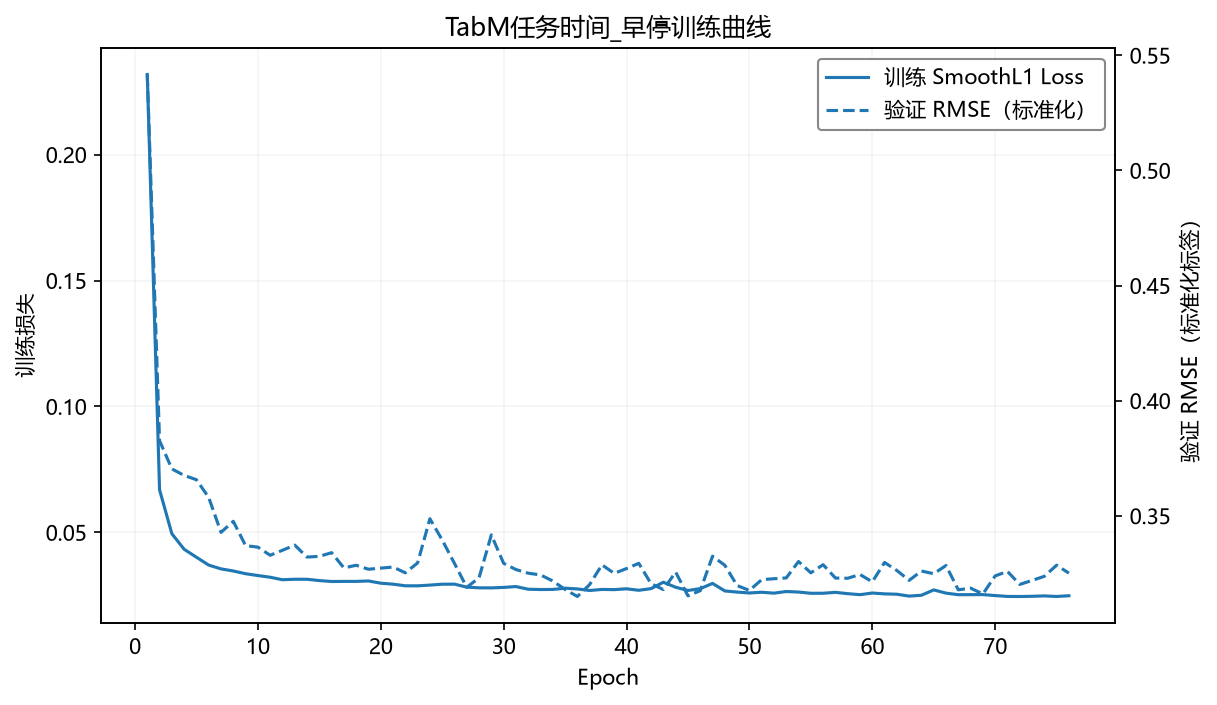

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务时间_早停训练曲线.png


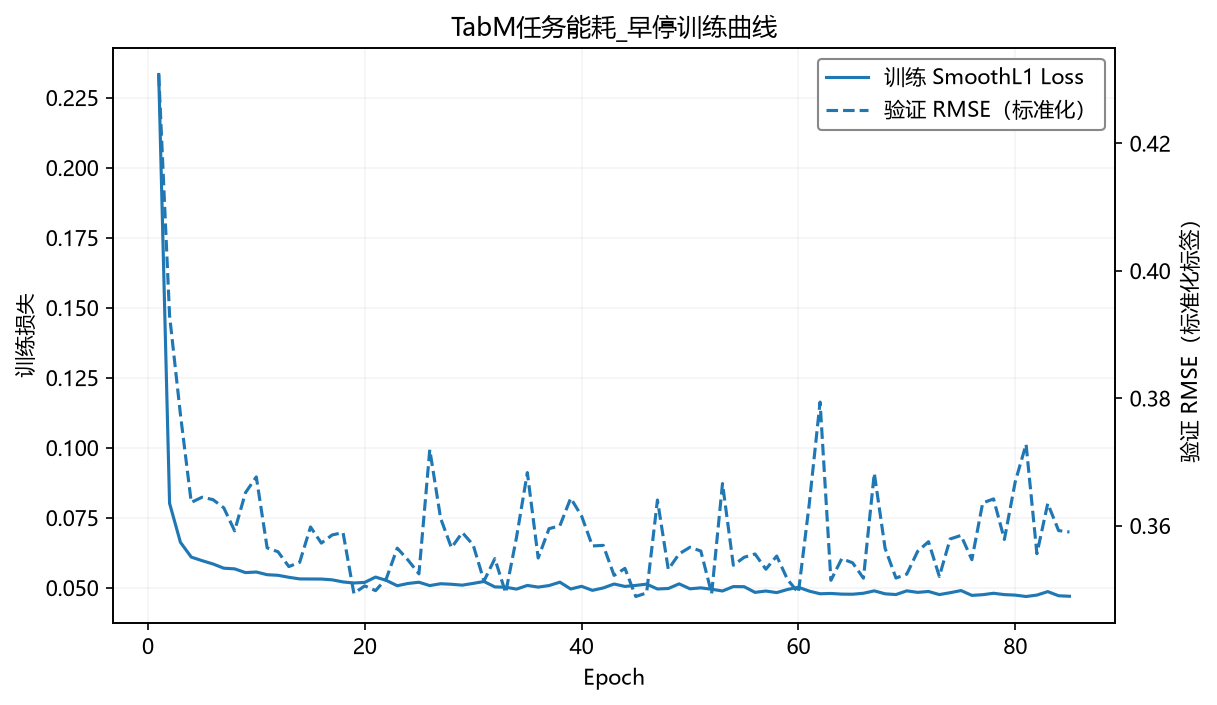

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务能耗_早停训练曲线.png


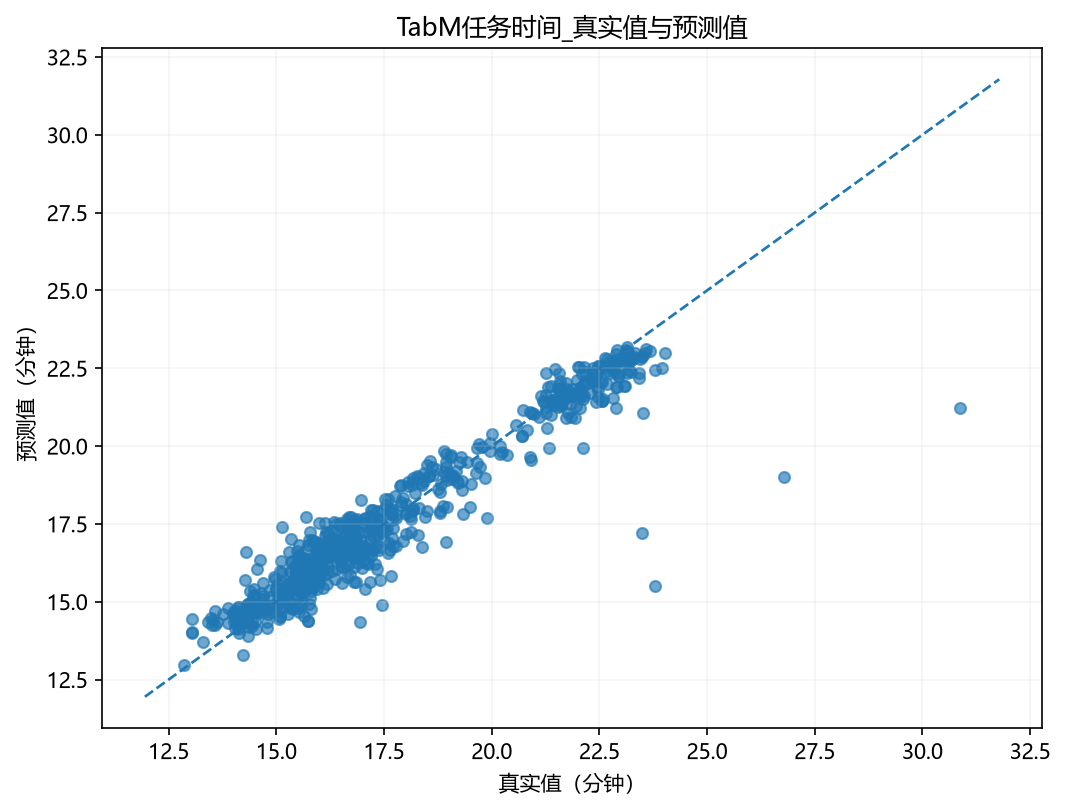

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务时间_真实值与预测值.png


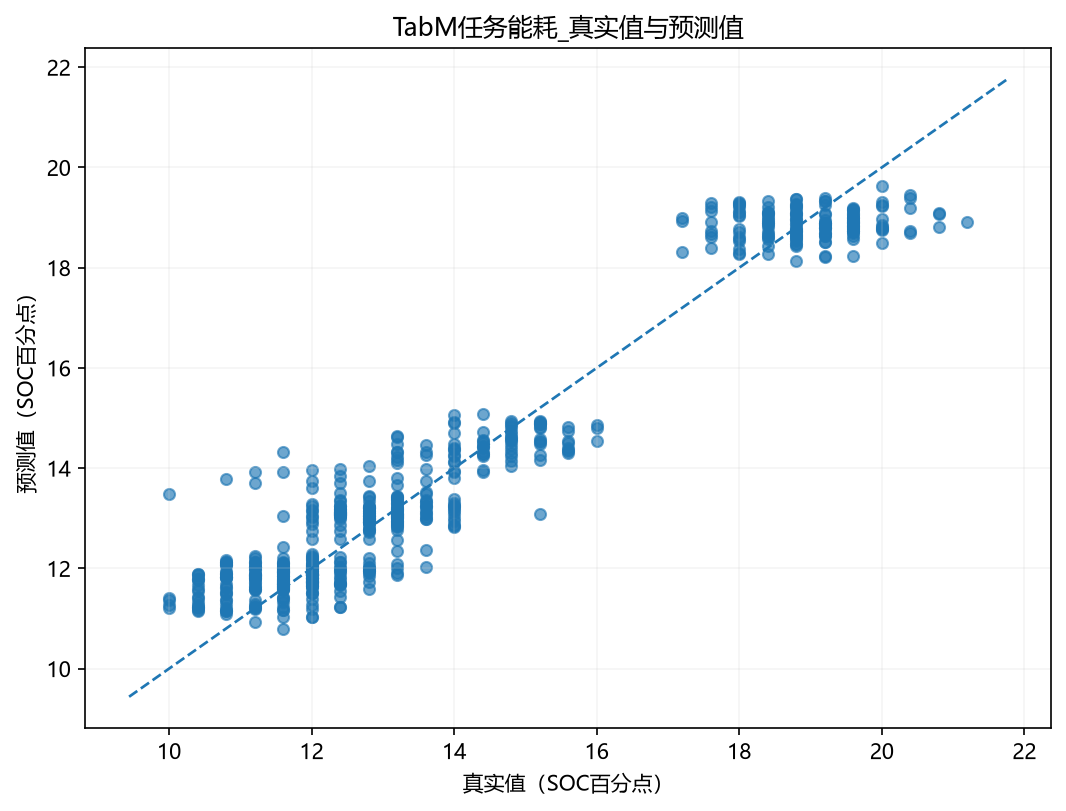

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务能耗_真实值与预测值.png


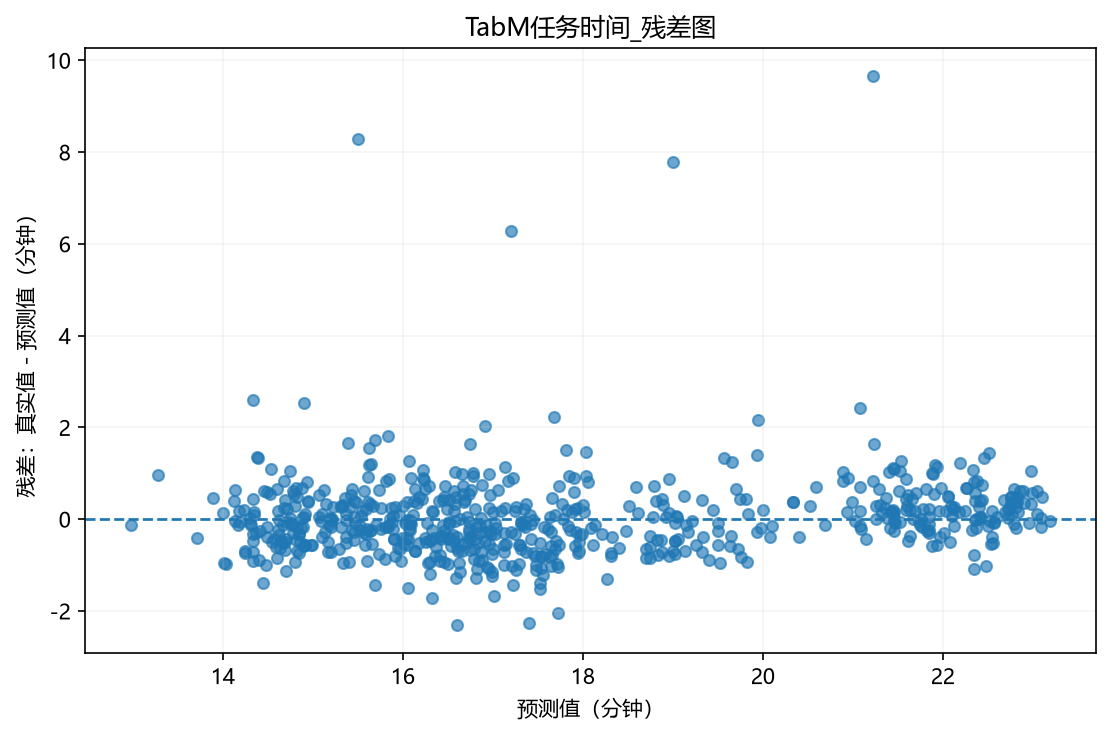

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务时间_残差图.png


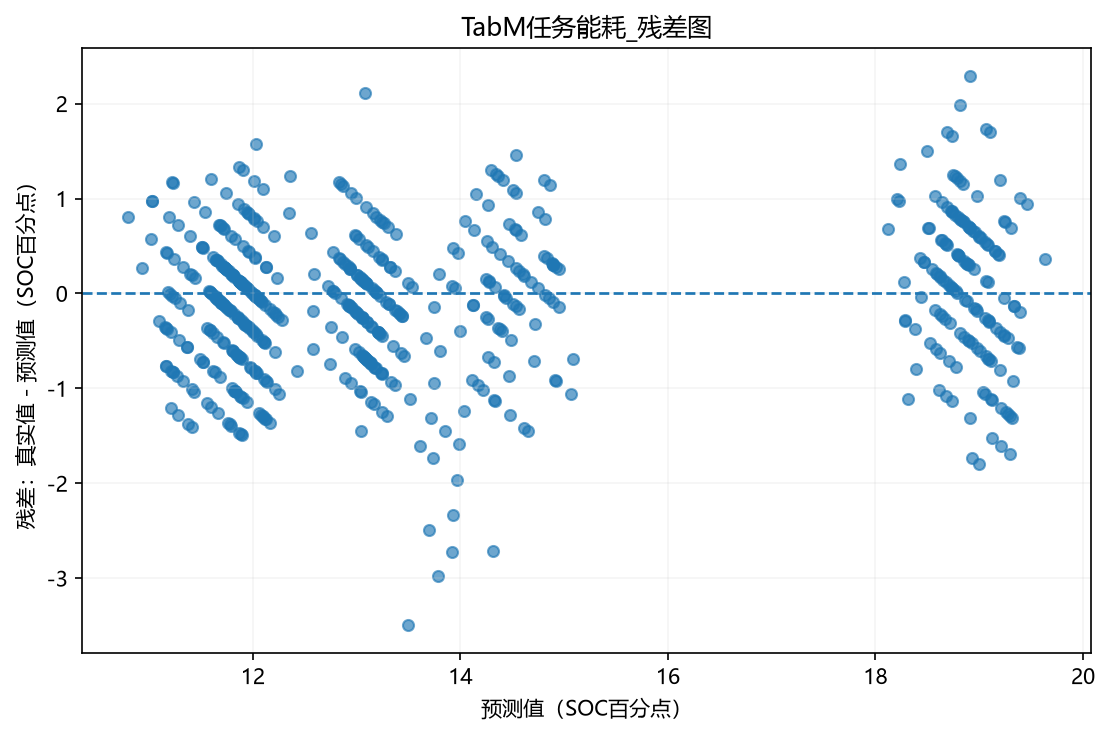

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务能耗_残差图.png


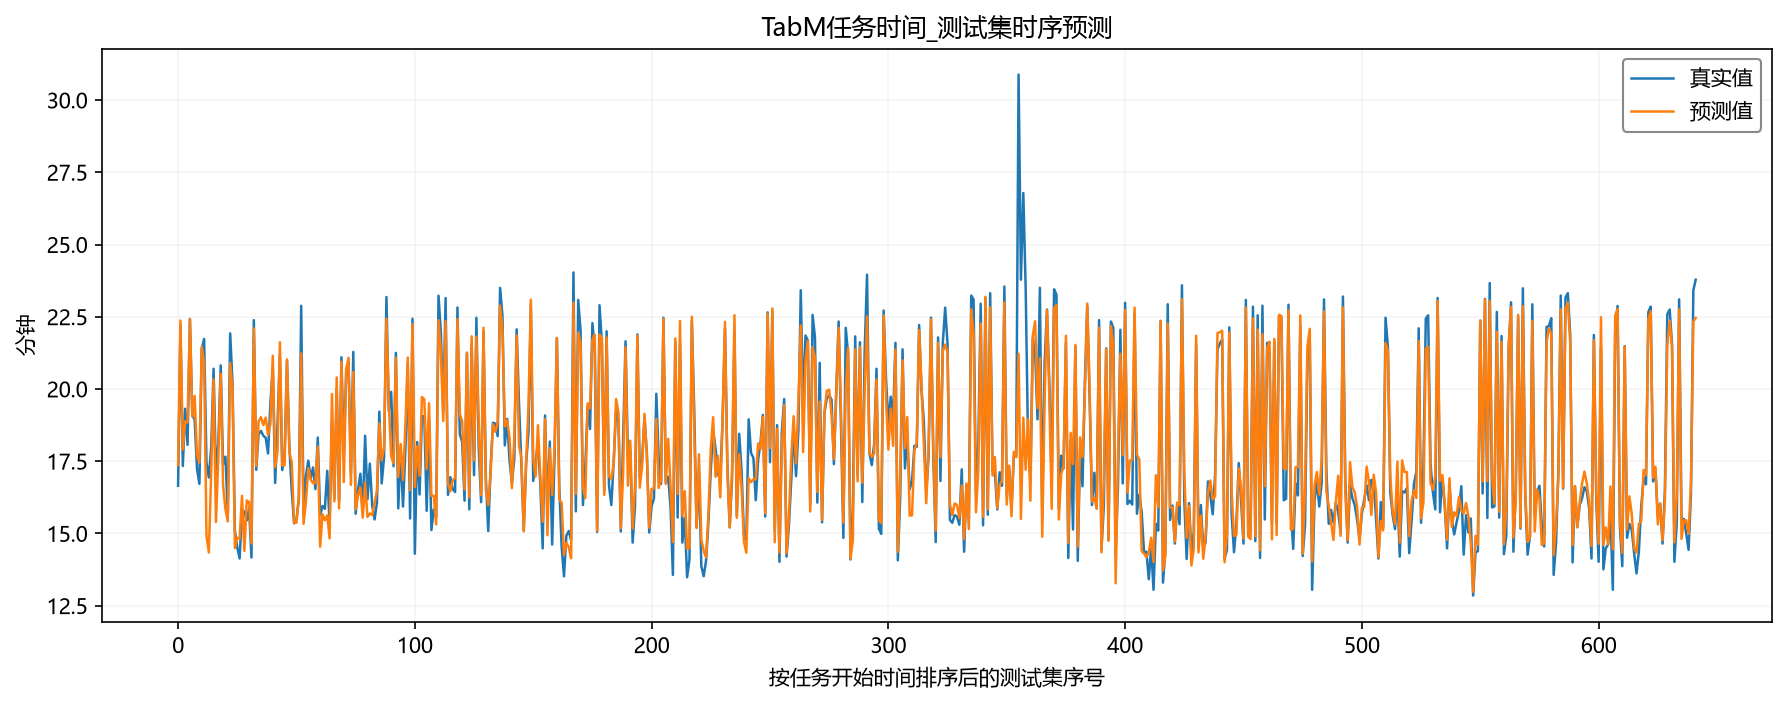

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务时间_测试集时序预测.png


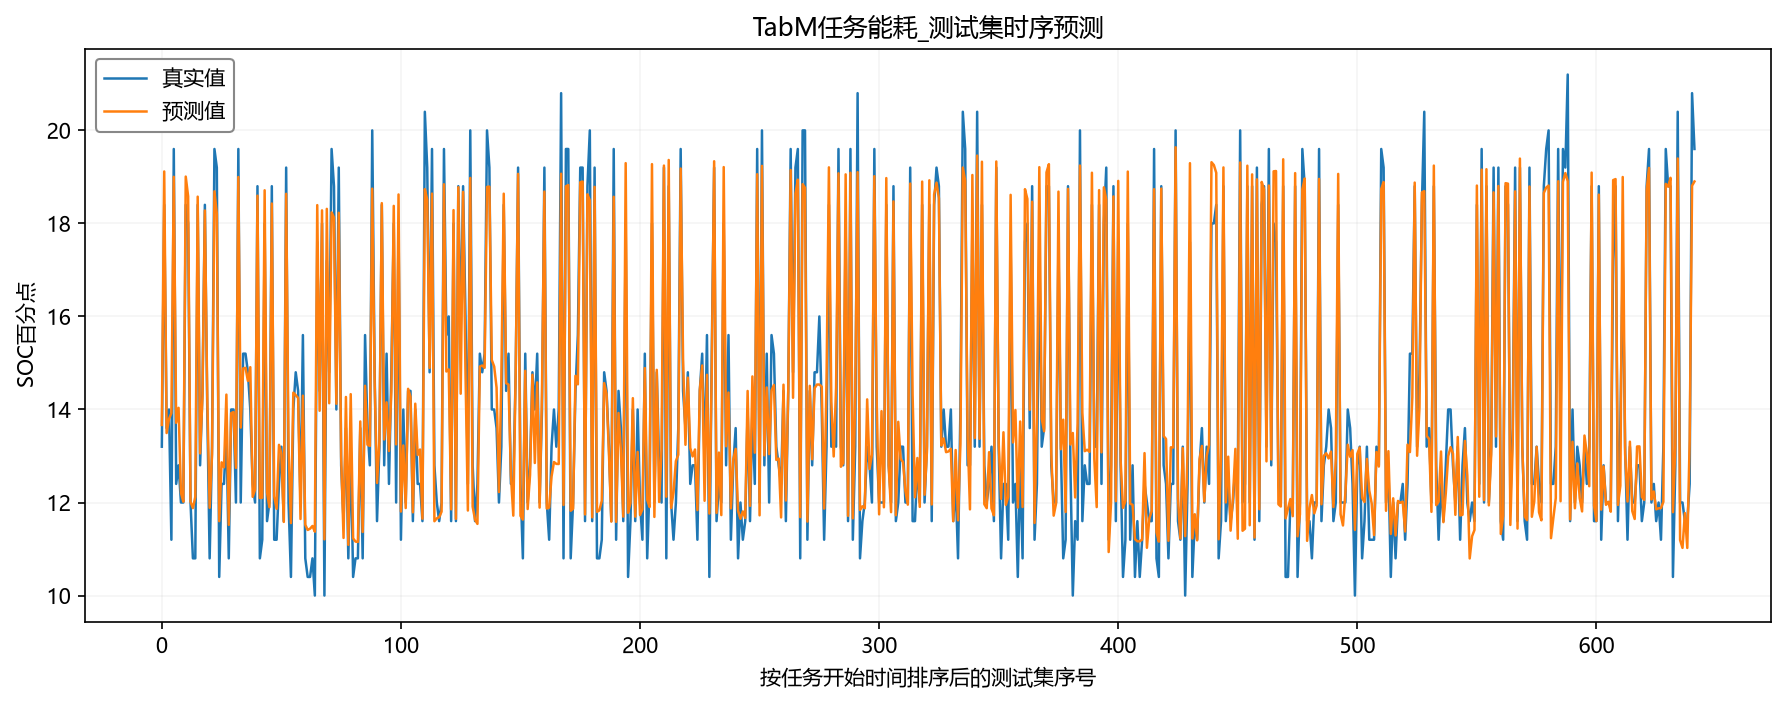

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务能耗_测试集时序预测.png


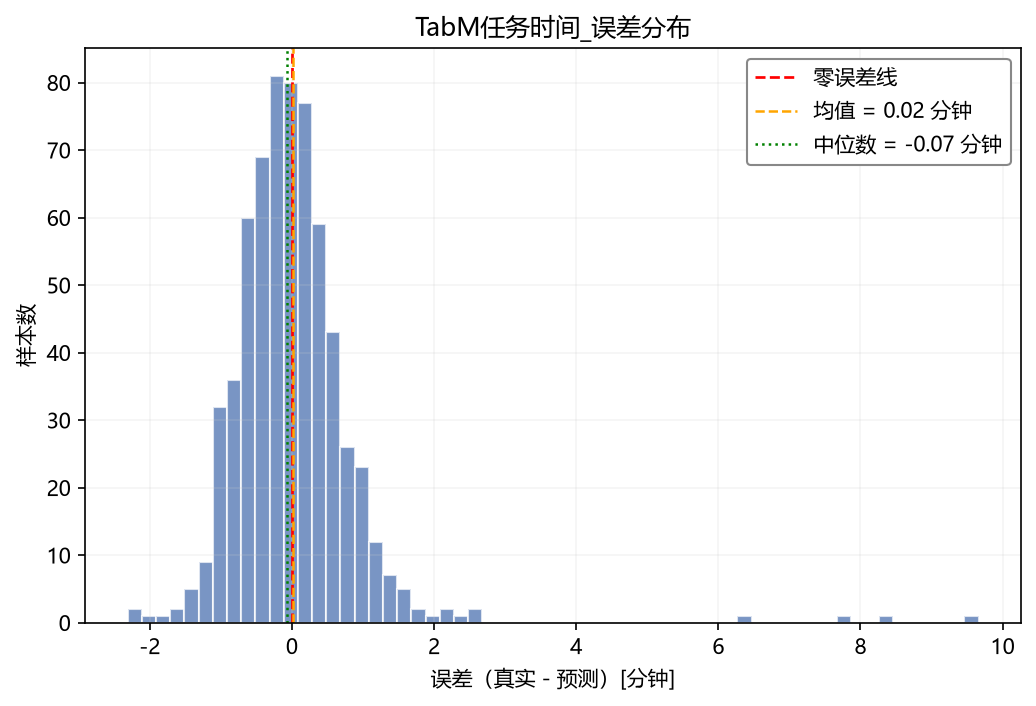

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务时间_误差分布.png


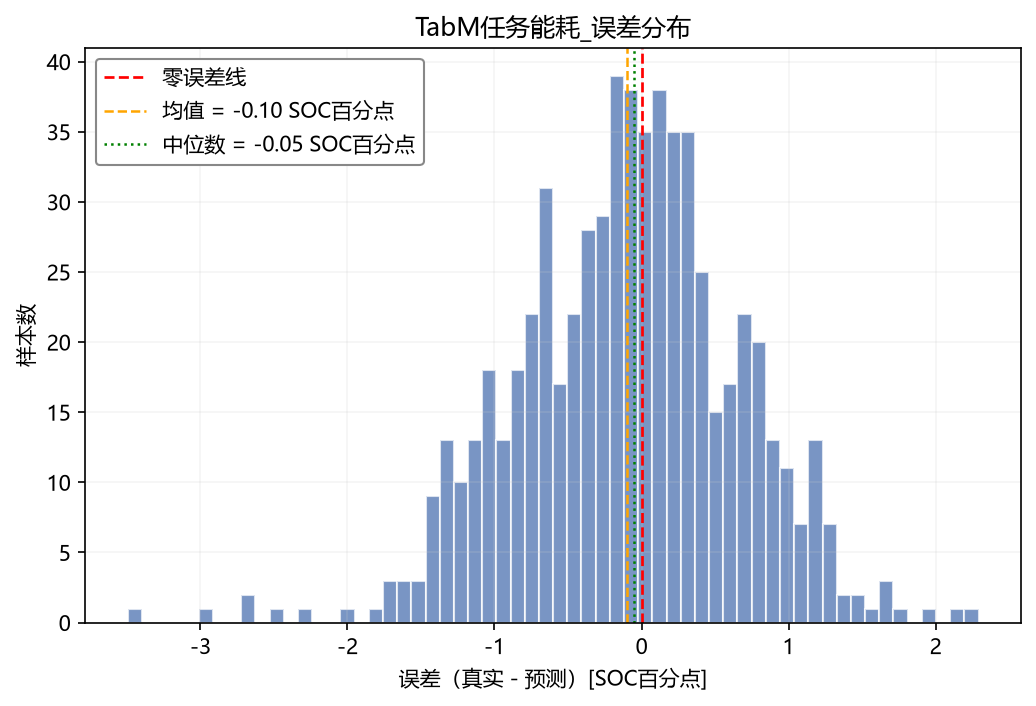

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务能耗_误差分布.png


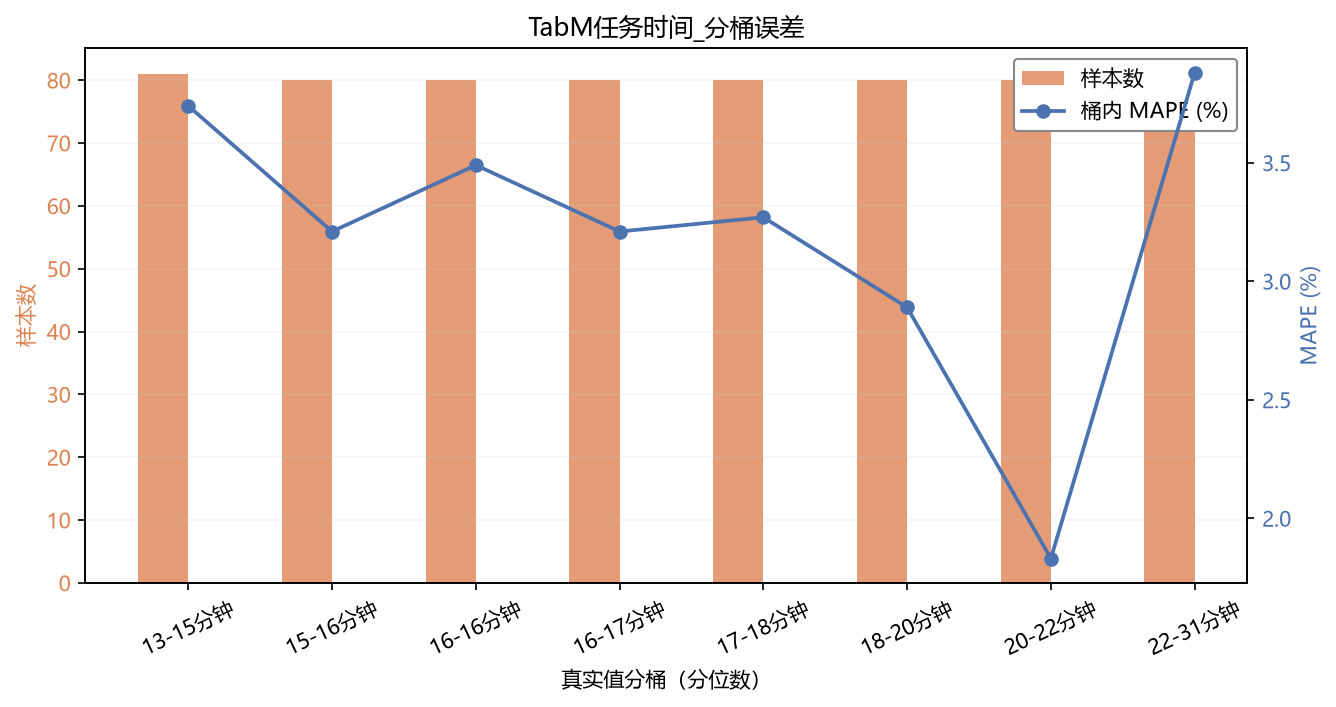

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务时间_分桶误差.png


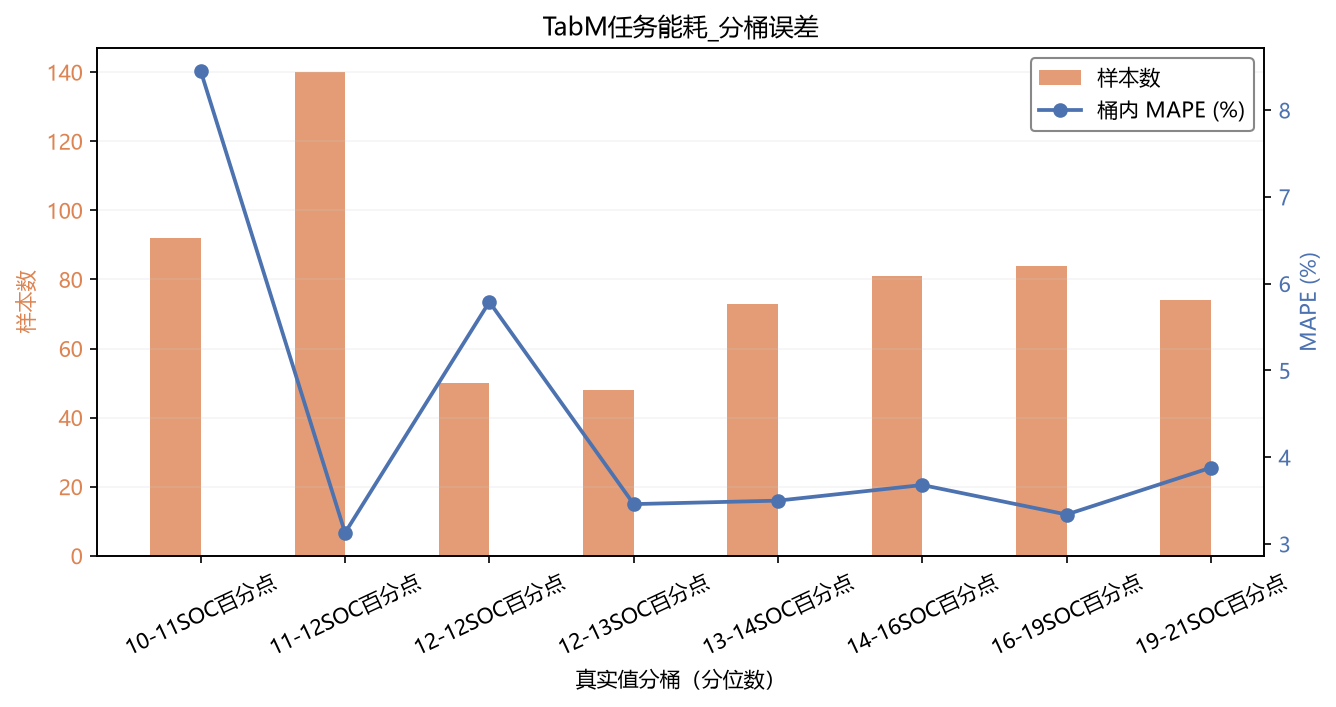

已保存： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots\TabM任务能耗_分桶误差.png


In [53]:
def safe_filename(title: str) -> str:
    name = re.sub(r"[^0-9A-Za-z一-鿿_-]+", "_", title).strip("_")
    return (name or "plot")[:120] + ".png"


def save_and_display(fig, title: str) -> None:
    path = PLOT_DIR / safe_filename(title)
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.close(fig)
    display(IPythonImage(filename=str(path)))
    print("已保存：", path)


def plot_training_history(history: Dict[str, list], title: str) -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, ax1 = plt.subplots(figsize=(8.2, 4.8))
    ax1.plot(epochs, history["train_loss"], label="训练 SmoothL1 Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("训练损失")
    ax1.grid(alpha=0.2)

    if history["val_rmse_std"]:
        ax2 = ax1.twinx()
        ax2.plot(epochs, history["val_rmse_std"], linestyle="--", label="验证 RMSE（标准化）")
        ax2.set_ylabel("验证 RMSE（标准化标签）")

        lines = ax1.get_lines() + ax2.get_lines()
        ax1.legend(lines, [line.get_label() for line in lines], loc="best")
    else:
        ax1.legend(loc="best")

    ax1.set_title(title)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_actual_vs_predicted(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    lower = float(min(y_true.min(), y_pred.min()))
    upper = float(max(y_true.max(), y_pred.max()))
    padding = max((upper - lower) * 0.05, 1e-6)

    fig, ax = plt.subplots(figsize=(7.2, 5.5))
    ax.scatter(y_true, y_pred, s=28, alpha=0.65)
    ax.plot(
        [lower - padding, upper + padding],
        [lower - padding, upper + padding],
        linestyle="--",
        linewidth=1.3,
    )
    ax.set_xlabel(f"真实值（{unit}）")
    ax.set_ylabel(f"预测值（{unit}）")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_residuals(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_true - y_pred

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.scatter(y_pred, residual, s=28, alpha=0.65)
    ax.axhline(0.0, linestyle="--", linewidth=1.3)
    ax.set_xlabel(f"预测值（{unit}）")
    ax.set_ylabel(f"残差：真实值 - 预测值（{unit}）")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_error_distribution(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    errors = y_true - y_pred

    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.hist(errors, bins=60, color="#4C72B0", alpha=0.75, edgecolor="white")
    ax.axvline(0.0, color="red", linestyle="--", linewidth=1.3, label="零误差线")
    ax.axvline(errors.mean(), color="orange", linestyle="--", linewidth=1.2,
               label=f"均值 = {errors.mean():.2f} {unit}")
    ax.axvline(np.median(errors), color="green", linestyle=":", linewidth=1.2,
               label=f"中位数 = {np.median(errors):.2f} {unit}")
    ax.set_xlabel(f"误差（真实 - 预测）[{unit}]")
    ax.set_ylabel("样本数")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_prediction_sequence(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    index = np.arange(len(y_true))

    fig, ax = plt.subplots(figsize=(12.0, 4.8))
    ax.plot(index, y_true, linewidth=1.2, label="真实值")
    ax.plot(index, y_pred, linewidth=1.2, label="预测值")
    ax.set_xlabel("按任务开始时间排序后的测试集序号")
    ax.set_ylabel(unit)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)

def plot_error_by_true_value_bins(y_true, y_pred, title: str, unit: str, n_bins: int = 8) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_err = np.abs(y_true - y_pred)

    df_tmp = pd.DataFrame({"true": y_true, "abs_err": abs_err})
    df_tmp["bin"] = pd.qcut(df_tmp["true"], q=n_bins, duplicates="drop")
    grouped = df_tmp.groupby("bin", observed=False).agg(
        count=("true", "size"),
        mean_true=("true", "mean"),
        mean_abs_err=("abs_err", "mean"),
    )
    grouped["mape"] = (grouped["mean_abs_err"] / grouped["mean_true"] * 100).round(2)

    fig, ax1 = plt.subplots(figsize=(9, 4.8))
    x = np.arange(len(grouped))
    w = 0.35
    ax1.bar(x - w/2, grouped["count"], width=w, color="#DD8452", alpha=0.8, label="样本数")
    ax1.set_xlabel("真实值分桶（分位数）")
    ax1.set_ylabel("样本数", color="#DD8452")
    ax1.tick_params(axis="y", labelcolor="#DD8452")

    ax2 = ax1.twinx()
    ax2.plot(x, grouped["mape"], color="#4C72B0", marker="o", linewidth=1.8, label="桶内 MAPE (%)")
    ax2.set_ylabel("MAPE (%)", color="#4C72B0")
    ax2.tick_params(axis="y", labelcolor="#4C72B0")

    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{b.left:.0f}-{b.right:.0f}{unit}" for b in grouped.index], rotation=25)
    ax1.set_title(title)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    ax1.grid(alpha=0.2, axis="y")
    fig.tight_layout()
    save_and_display(fig, title)


# 训练曲线
plot_training_history(time_bundle["history"], "TabM任务时间_早停训练曲线")
plot_training_history(energy_bundle["history"], "TabM任务能耗_早停训练曲线")

# 真实值与预测值
plot_actual_vs_predicted(y_time_test, time_pred, "TabM任务时间_真实值与预测值", "分钟")
plot_actual_vs_predicted(y_energy_test, energy_pred, "TabM任务能耗_真实值与预测值", "SOC百分点")

# 残差
plot_residuals(y_time_test, time_pred, "TabM任务时间_残差图", "分钟")
plot_residuals(y_energy_test, energy_pred, "TabM任务能耗_残差图", "SOC百分点")

# 按时间顺序对比
plot_prediction_sequence(y_time_test, time_pred, "TabM任务时间_测试集时序预测", "分钟")
plot_prediction_sequence(y_energy_test, energy_pred, "TabM任务能耗_测试集时序预测", "SOC百分点")

# 误差分布
plot_error_distribution(y_time_test, time_pred, "TabM任务时间_误差分布", "分钟")
plot_error_distribution(y_energy_test, energy_pred, "TabM任务能耗_误差分布", "SOC百分点")

# === 新增图：真实值分桶误差 ===
plot_error_by_true_value_bins(y_time_test, time_pred, "TabM任务时间_分桶误差", "分钟")
plot_error_by_true_value_bins(y_energy_test, energy_pred, "TabM任务能耗_分桶误差", "SOC百分点")

## 9. 保存指标、预测结果和模型

In [54]:
metrics_table.to_csv(
    OUTPUT_DIR / "tabm_test_metrics.csv",
    encoding="utf-8-sig",
)

time_prediction_result.to_csv(
    OUTPUT_DIR / "tabm_time_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

energy_prediction_result.to_csv(
    OUTPUT_DIR / "tabm_energy_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

if SAVE_MODELS:
    # ========================================================
    # 时间模型
    # ========================================================
    torch.save(
        {
            "state_dict": (
                time_bundle["model"]
                .state_dict()
            ),
            "raw_feature_columns": TIME_FEATURE_COLS,
            "numeric_feature_columns": (
                TIME_NUMERIC_FEATURE_COLS
            ),
            "categorical_feature_columns": (
                TIME_CATEGORICAL_FEATURE_COLS
            ),
            "model_input_feature_names": (
                time_bundle[
                    "model_input_feature_names"
                ]
            ),
            "n_features_after_preprocessing": (
                time_bundle[
                    "n_features_after_preprocessing"
                ]
            ),
            "model_config": TABM_CONFIG,
            "best_epoch": int(
                time_bundle["best_epoch"]
            ),
            "target": TIME_TARGET,
        },
        OUTPUT_DIR
        / "tabm_time_state.pt",
    )

    joblib.dump(
        {
            "feature_preprocessor": (
                time_bundle[
                    "feature_preprocessor"
                ]
            ),
            "target_scaler": (
                time_bundle[
                    "target_scaler"
                ]
            ),
        },
        OUTPUT_DIR
        / "tabm_time_preprocessors.joblib",
    )

    # ========================================================
    # 能耗模型
    # ========================================================
    torch.save(
        {
            "state_dict": (
                energy_bundle["model"]
                .state_dict()
            ),
            "raw_feature_columns": ENERGY_FEATURE_COLS,
            "numeric_feature_columns": (
                ENERGY_NUMERIC_FEATURE_COLS
            ),
            "categorical_feature_columns": (
                ENERGY_CATEGORICAL_FEATURE_COLS
            ),
            "model_input_feature_names": (
                energy_bundle[
                    "model_input_feature_names"
                ]
            ),
            "n_features_after_preprocessing": (
                energy_bundle[
                    "n_features_after_preprocessing"
                ]
            ),
            "model_config": TABM_CONFIG,
            "best_epoch": int(
                energy_bundle["best_epoch"]
            ),
            "target": ENERGY_TARGET,
        },
        OUTPUT_DIR
        / "tabm_energy_state.pt",
    )

    joblib.dump(
        {
            "feature_preprocessor": (
                energy_bundle[
                    "feature_preprocessor"
                ]
            ),
            "target_scaler": (
                energy_bundle[
                    "target_scaler"
                ]
            ),
        },
        OUTPUT_DIR
        / "tabm_energy_preprocessors.joblib",
    )

metadata = {
    "data_file": str(DATA_FILE),
    "output_dir": str(OUTPUT_DIR),
    "base_sample_count": int(len(df)),
    "time_sample_count": int(len(time_df)),
    "energy_sample_count": int(len(energy_df)),
    "time_train_count": int(len(time_train_df)),
    "time_test_count": int(len(time_test_df)),
    "energy_train_count": int(len(energy_train_df)),
    "energy_test_count": int(len(energy_test_df)),

    "time_numeric_feature_columns": (
        TIME_NUMERIC_FEATURE_COLS
    ),
    "time_categorical_feature_columns": (
        TIME_CATEGORICAL_FEATURE_COLS
    ),
    "time_raw_feature_columns": (
        TIME_FEATURE_COLS
    ),

    "energy_numeric_feature_columns": (
        ENERGY_NUMERIC_FEATURE_COLS
    ),
    "energy_categorical_feature_columns": (
        ENERGY_CATEGORICAL_FEATURE_COLS
    ),
    "energy_raw_feature_columns": (
        ENERGY_FEATURE_COLS
    ),

    "time_n_features_after_preprocessing": (
        time_bundle[
            "n_features_after_preprocessing"
        ]
    ),
    "energy_n_features_after_preprocessing": (
        energy_bundle[
            "n_features_after_preprocessing"
        ]
    ),

    "device": str(DEVICE),
    "tabm_config": TABM_CONFIG,
    "time_best_epoch": int(
        time_bundle["best_epoch"]
    ),
    "energy_best_epoch": int(
        energy_bundle["best_epoch"]
    ),
    "time_metrics": time_metrics,
    "energy_metrics": energy_metrics,
}

with (
    OUTPUT_DIR
    / "tabm_run_metadata.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    "全部结果已保存到：",
    OUTPUT_DIR.resolve(),
)
print(
    "图表目录：",
    PLOT_DIR.resolve(),
)


全部结果已保存到： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster
图表目录： C:\Users\14993\Desktop\新版\BoLei-DataMining\target\TabM_TimeEnergy_V7_ODCluster\plots


## 输出文件

运行完成后，输出目录包括：

- `tabm_test_metrics.csv`：时间与能耗测试集 MAE、RMSE、R²；
- `tabm_time_test_predictions.csv`：时间模型每个测试任务的真实值、预测值和残差；
- `tabm_energy_test_predictions.csv`：能耗模型每个测试任务的真实值、预测值和残差；
- `plots/`：保持原代码风格的 8 张图（两条训练曲线、两张真实/预测散点图、两张残差图、两张时序预测图）；
- `tabm_time_state.pt`、`tabm_energy_state.pt`：两个模型的参数；
- `tabm_time_preprocessors.joblib`、`tabm_energy_preprocessors.joblib`：两套独立的填补器、特征标准化器和标签标准化器；
- `tabm_run_metadata.json`：运行配置、各自特征列和测试指标。


In [55]:
print("text.color:", plt.rcParams["text.color"])
print("legend.labelcolor:", plt.rcParams["legend.labelcolor"])
print("legend.framealpha:", plt.rcParams["legend.framealpha"])
print("legend.fancybox:", plt.rcParams["legend.fancybox"])
print("patch.facecolor:", plt.rcParams["patch.facecolor"])

# 测试画一个最简单的带中文图例的图，看是不是空白
fig, ax = plt.subplots(figsize=(4,3))
ax.plot([1,2,3], [1,2,3], label="训练 SmoothL1 Loss")
leg = ax.legend()
print("\nlegend 对象文字颜色：", [t.get_color() for t in leg.get_texts()])
print("legend 对象文字内容：", [t.get_text() for t in leg.get_texts()])
plt.close(fig)

text.color: black
legend.labelcolor: black
legend.framealpha: 1.0
legend.fancybox: True
patch.facecolor: C0

legend 对象文字颜色： [array([0., 0., 0., 1.])]
legend 对象文字内容： ['训练 SmoothL1 Loss']
